# 📊 Analyse Géospatiale de l'Inclusion Financière en Haïti
## Capstone G10 · Programme FRST/SDMIA · Faculté des Sciences, UEH

---


**Équipe — Capstone Groupe 10 (G10) :**
- Jean Baptiste Kendy — *Coordinateur*
- Louis Wilson Junior
- Jonathan François Alcena

**Encadrant(e) :** *À compléter*
**Date :** Juillet 2026
**Dépôt GitHub :** [Projet_Capstone_G10](https://github.com/Jean-Baptiste-Kendy/Projet_Capstone_G10)

### Plan du notebook

| Section | Contenu | Sortie principale |
|---|---|---|
| **0** | Installation & Imports | — |
| **1** | Chemins des fichiers sources (dépôt GitHub) | — |
| **2** | Import BRH (Excel) + IHSI (Excel) | `df_brh`, `df_ihsi` |
| **3** | Géolocalisation des prestataires BRH + jointure avec `hti_admin2.geojson` | `gdf_brh_geo` → CSV/GeoJSON |
| **4** | Jointure exacte BRH ↔ IHSI sur `id_commune` | `matrice_brh_ihsi` |
| **5** | Variables contextuelles WBG 2017 (6 strates) | `matrice` |
| **5E** | Variables qualitatives dérivées (urbanisation, densité, diversité de services) | `matrice` |
| **5F** | Pauvreté et privation spatiale (proxy BID 2014, jointure sur `id_commune`) | `matrice` |
| **5G** | Variables qualitatives supplémentaires (taille population/ménage, profil de services financiers) | `matrice` |
| **5H** | Préparation AFCM — séparation variables actives / supplémentaires | `mca` (contrôle) |
| **5I** | Vérification empirique des contributions des variables actives | — (contrôle) |
| **6** | Table finale + export | `matrice_finale` → `G10_Dictionnaire_Donnees_Finale.csv` |
| **7** | Méthodologie, limites et variables non disponibles | — |

> **Fichiers sources (dossier `data/` du dépôt GitHub) :**
> - `G10_Donnees2017_Services_Financiers_BRH.xlsx`
> - `population_commune_IHSI2024_G10.xlsx`
> - `hti_admin_boundaries/hti_admin2.geojson`
> - `base_communes_proxy_pauvrete_privation.xlsx`

> ⚠️ **Point clé sur les jointures** : BRH, IHSI et le fichier de pauvreté partagent tous la
> **même clé `id_commune`** (format `C-001`…`C-140`), vérifiée identique et unique entre les
> fichiers. Toutes les jointures entre ces fichiers (Sections 4 et 5F) utilisent donc un
> `merge(..., on='id_commune', how='inner', validate='1:1')` — **jointure exacte, sans
> correspondance approximative de noms**.
>
> Le fichier `hti_admin2.geojson` est le seul qui n'a pas de colonne `id_commune` (il utilise son
> propre code `adm2_pcode`, ex. `HT0812`). Une table de correspondance `id_commune ↔ adm2_pcode`
> est donc construite une seule fois en Section 3C, par correspondance exacte de nom normalisé
> (136/140 communes) + **4 corrections manuelles documentées et vérifiées individuellement**
> (voir Section 7 pour le détail) — jamais de correspondance floue à l'exécution.

> 📋 **Voir la Section 7** pour le détail complet de la méthodologie, des limites rencontrées et
> des variables recherchées mais non disponibles (couverture réseau, alphabétisation, IPM
> officiel complet).


---
## Section 0 — Installation & Imports

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
#  SECTION 0 — INSTALLATION & IMPORTS
# ═══════════════════════════════════════════════════════════════════════════

!pip install geopandas requests pandas shapely matplotlib openpyxl -q
print('✅ Librairies installées')


✅ Librairies installées


In [2]:
import os
import warnings
import unicodedata
import re
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from IPython.display import display

try:
    from google.colab import files
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 160)

SEED = 42
rng = np.random.default_rng(SEED)

print('✅ Imports réussis')
print(f'   pandas     {pd.__version__}')
print(f'   geopandas  {gpd.__version__}')
print(f'   Colab      {IN_COLAB}')


✅ Imports réussis
   pandas     2.2.2
   geopandas  1.1.3
   Colab      True


---
## Section 1A — Clonage du dépôt GitHub (Google Colab uniquement)

Sur Colab, l'environnement démarre vide : il faut d'abord cloner le dépôt pour que le dossier `data/` soit disponible. Cette cellule ne fait rien si le notebook tourne déjà en local depuis le dépôt cloné.


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
#  SECTION 1A — CLONAGE DU DÉPÔT GITHUB (Colab uniquement)
# ═══════════════════════════════════════════════════════════════════════════

import os

REPO_URL = "https://github.com/Jean-Baptiste-Kendy/Projet_Capstone_G10.git"
REPO_DOSSIER = "Projet_Capstone_G10"

try:
    import google.colab
    EST_COLAB = True
except ImportError:
    EST_COLAB = False

if EST_COLAB:
    if not os.path.isdir(REPO_DOSSIER):
        print(f"📥 Clonage de {REPO_URL} ...")
        !git clone {REPO_URL}
    else:
        print(f"✅ Dépôt déjà cloné : {REPO_DOSSIER}")
    %cd {REPO_DOSSIER}
    print(f"📂 Répertoire de travail : {os.getcwd()}")
else:
    print("ℹ️ Exécution locale détectée — vérifiez que vous êtes bien à la racine du dépôt cloné.")


📥 Clonage de https://github.com/Jean-Baptiste-Kendy/Projet_Capstone_G10.git ...
Cloning into 'Projet_Capstone_G10'...
remote: Enumerating objects: 28, done.
remote: Counting objects: 100% (28/28), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 28 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (28/28), 857.14 KiB | 3.08 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/Projet_Capstone_G10
📂 Répertoire de travail : /content/Projet_Capstone_G10


---
## Section 1 — Chemins des fichiers sources (dépôt GitHub)

Les fichiers sources (BRH, IHSI, geojson, pauvreté) sont stockés dans le dossier `data/` du dépôt GitHub (voir le README pour la structure complète).
Ce notebook doit être exécuté **depuis la racine du dépôt cloné** pour que les chemins relatifs ci-dessous fonctionnent.


In [5]:
# ═══════════════════════════════════════════════════════════════════════════
#  SECTION 1 — CHEMINS DES FICHIERS SOURCES (dépôt GitHub)
# ═══════════════════════════════════════════════════════════════════════════

# ── Dossier data/ du dépôt (chemins relatifs, plus de montage Drive) ───────
DOSSIER_DATA = "data"

CHEMIN_BRH     = f"{DOSSIER_DATA}/G10_Donnees2017_Services_Financiers_BRH.xlsx"
CHEMIN_IHSI    = f"{DOSSIER_DATA}/population_commune_IHSI2024_G10.xlsx"
CHEMIN_GEOJSON = f"{DOSSIER_DATA}/hti_admin_boundaries/hti_admin2.geojson"

print("=" * 65)
print("  SECTION 1 — VÉRIFICATION DES FICHIERS")
print("=" * 65)

for chemin, label in [(CHEMIN_BRH, "BRH"), (CHEMIN_IHSI, "IHSI"), (CHEMIN_GEOJSON, "GEOJSON")]:
    if os.path.exists(chemin):
        taille = os.path.getsize(chemin) / 1024
        print(f"   ✅ {label:<8} trouvé ({taille:.1f} Ko) : {chemin}")
    else:
        print(f"   ❌ {label:<8} INTROUVABLE : {chemin}")
        print(f"      → Vérifiez que le notebook s'exécute depuis la racine du dépôt cloné")


  SECTION 1 — VÉRIFICATION DES FICHIERS
   ✅ BRH      trouvé (27.5 Ko) : data/G10_Donnees2017_Services_Financiers_BRH.xlsx
   ✅ IHSI     trouvé (28.1 Ko) : data/population_commune_IHSI2024_G10.xlsx
   ✅ GEOJSON  trouvé (2388.7 Ko) : data/hti_admin_boundaries/hti_admin2.geojson


---
## Section 2 — Import des données BRH et IHSI (Étape 1)

Import brut des deux fichiers Excel, sans fusion. Chacun garde sa propre clé `id_commune`.

- **BRH** — onglet `Services_Financiers_Communes` : ligne 0 = titre (ignorée), ligne 1 = en-têtes,
  ligne 2 = catégories BRH (ignorée), lignes 3+ = données (140 communes).
- **IHSI** — onglet `Population_Communes_IHSI` : en-têtes directement en ligne 0.


In [6]:
# ═══════════════════════════════════════════════════════════════════════════
#  SECTION 2A — IMPORT BRH
# ═══════════════════════════════════════════════════════════════════════════

SHEET_BRH = "Services_Financiers_Communes"

# skiprows=1 ignore la ligne de titre ; header=0 (relatif) = ligne des noms de
# colonnes ; skiprows=[2] ignore la ligne des catégories BRH
df_brh = pd.read_excel(CHEMIN_BRH, sheet_name=SHEET_BRH, header=1, skiprows=[2])

# Normalisation des noms de colonnes
df_brh.columns = (
    df_brh.columns.str.strip().str.lower()
    .str.replace(' ', '_', regex=False)
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)

# id_commune en texte propre (clé de jointure — ne jamais convertir en nombre)
df_brh['id_commune'] = df_brh['id_commune'].astype(str).str.strip()

print("=" * 65)
print("  SECTION 2A — DONNÉES BRH")
print("=" * 65)
print(f"✅ {len(df_brh)} communes × {len(df_brh.columns)} colonnes")
print(f"   id_commune unique : {df_brh['id_commune'].nunique()}")
display(df_brh.head(3))


  SECTION 2A — DONNÉES BRH
✅ 140 communes × 29 colonnes
   id_commune unique : 140


,id_commune,nom_commune,arrondissement,mt_agence_sogexpress,mt_agence_unitransfer,mt_agent_unitransfer,mt_agent_capital_transfert,mt_agent_sogexpress,mt_agent_rapide_transfer,anb_moncash_digicel,anb_lajancash_haitipay,bc_agence_unibank,bc_agence_sogebank,bc_agence_banca_nac_credit,bc_agence_capital_bank,bc_agence_union_haitienne,bc_agence_autres_banques,bc_atm_sogebank,bc_atm_unibank,imf_fonkoze,imf_micro_credit_national,imf_acme,imf_sogesol,imf_micro_credit_capital,imf_finca_haiti,imf_initiative_developpement,imf_fhaf,imf_autres,cp_autres_caisses_populaires
0,C-001,Port-au-Prince,Port-au-Prince,15.0,7.0,39.0,38.0,18.0,22.0,226.0,22.0,8.0,7.0,3.0,2.0,1.0,1.0,20.0,10.0,1.0,4.0,5.0,2.0,1.0,NaN,1.0,2.0,NaN,6.0
1,C-002,Delmas,Port-au-Prince,13.0,6.0,53.0,35.0,17.0,44.0,163.0,21.0,6.0,5.0,4.0,4.0,1.0,5.0,23.0,14.0,NaN,1.0,2.0,2.0,NaN,NaN,1.0,NaN,2.0,2.0
2,C-003,Cité Soleil,Port-au-Prince,NaN,NaN,2.0,6.0,NaN,1.0,18.0,3.0,1.0,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
#  SECTION 2B — IMPORT IHSI
# ═══════════════════════════════════════════════════════════════════════════

SHEET_IHSI = "Population_Communes_IHSI"

df_ihsi = pd.read_excel(CHEMIN_IHSI, sheet_name=SHEET_IHSI)

df_ihsi.columns = (
    df_ihsi.columns.str.strip().str.lower()
    .str.replace(' ', '_', regex=False)
    .str.replace(r'[^a-z0-9_]', '', regex=True)
)

df_ihsi['id_commune'] = df_ihsi['id_commune'].astype(str).str.strip()

print("=" * 65)
print("  SECTION 2B — DONNÉES IHSI")
print("=" * 65)
print(f"✅ {len(df_ihsi)} communes × {len(df_ihsi.columns)} colonnes")
print(f"   id_commune unique : {df_ihsi['id_commune'].nunique()}")
display(df_ihsi.head(3))

# ── Contrôle de cohérence de la clé avant toute jointure ─────────────────
communs = set(df_brh['id_commune']) & set(df_ihsi['id_commune'])
seulement_brh  = set(df_brh['id_commune'])  - set(df_ihsi['id_commune'])
seulement_ihsi = set(df_ihsi['id_commune']) - set(df_brh['id_commune'])

print(f"\n   id_commune communs BRH∩IHSI : {len(communs)}")
if seulement_brh:
    print(f"   ⚠️ Présents seulement dans BRH  : {sorted(seulement_brh)}")
if seulement_ihsi:
    print(f"   ⚠️ Présents seulement dans IHSI : {sorted(seulement_ihsi)}")
if not seulement_brh and not seulement_ihsi:
    print("   ✅ Clés parfaitement alignées — jointure exacte possible sans perte")


  SECTION 2B — DONNÉES IHSI
✅ 140 communes × 17 colonnes
   id_commune unique : 140


,id_commune,nom_commune,arrondissement,population_totale,population_urbaine,pop_masculine,pop_masculine_urbaine,pop_feminine,pop_feminine_urbaine,pop_masculine_18_plus,pop_masculine_18_plus_urbaine,pop_feminine_18_plus,pop_feminine_18_plus_urbaine,nb_menages,nb_menages_urbains,superficie_km2,superficie_urbaine_km2
0,C-001,Port-au-Prince,Port-au-Prince,989447,988438,468815,468450,520632,519988,322606,322364,358875,358458,213294,213077,36.04,25.29
1,C-002,Delmas,Port-au-Prince,396122,396122,188524,188524,207598,207598,125356,125356,134822,134822,83739,83739,27.74,27.74
2,C-003,Cité Soleil,Port-au-Prince,265687,265687,130716,130716,134971,134971,86918,86918,87653,87653,59435,59435,21.81,21.81



   id_commune communs BRH∩IHSI : 140
   ✅ Clés parfaitement alignées — jointure exacte possible sans perte


---
## Section 3 — Géolocalisation des prestataires BRH + jointure avec `hti_admin2.geojson` (Étape 2)

1. Regroupement des colonnes BRH par type de prestataire (Maison de Transfert, Agent Non Bancaire, Banque…)
2. Chargement de `hti_admin2.geojson` (140 polygones communaux)
3. Construction d'une **table de correspondance `id_commune ↔ adm2_pcode`** (le geojson n'a pas
   `id_commune`) — correspondance exacte de nom normalisé, avec 4 corrections manuelles documentées
4. Génération d'un point GPS par commune × type de prestataire, placé dans le polygone communal
5. Export du tableau géolocalisé en CSV et GeoJSON


In [8]:
# ═══════════════════════════════════════════════════════════════════════════
#  SECTION 3A — REGROUPEMENT DES PRESTATAIRES BRH PAR TYPE
# ═══════════════════════════════════════════════════════════════════════════

GROUPES_SERVICES = {
    "Maison de Transfert": [
        "mt_agence_sogexpress", "mt_agence_unitransfer",
        "mt_agent_unitransfer", "mt_agent_capital_transfert",
        "mt_agent_sogexpress", "mt_agent_rapide_transfer",
    ],
    "Agent Non Bancaire": ["anb_moncash_digicel", "anb_lajancash_haitipay"],
    "Banque": [
        "bc_agence_unibank", "bc_agence_sogebank",
        "bc_agence_banca_nac_credit", "bc_agence_capital_bank",
        "bc_agence_union_haitienne", "bc_agence_autres_banques",
    ],
    "ATM": ["bc_atm_sogebank", "bc_atm_unibank"],
    "Microfinance": [
        "imf_fonkoze", "imf_micro_credit_national", "imf_acme",
        "imf_sogesol", "imf_micro_credit_capital", "imf_finca_haiti",
        "imf_initiative_developpement", "imf_fhaf", "imf_autres",
    ],
    "Caisse Populaire": ["cp_autres_caisses_populaires"],
}

cols_service_brutes = [c for g in GROUPES_SERVICES.values() for c in g]
for col in cols_service_brutes:
    if col in df_brh.columns:
        df_brh[col] = pd.to_numeric(df_brh[col], errors='coerce').fillna(0)

df_brh_agg = df_brh[['id_commune', 'nom_commune', 'arrondissement']].copy()
for type_presta, cols_groupe in GROUPES_SERVICES.items():
    cols_presentes = [c for c in cols_groupe if c in df_brh.columns]
    df_brh_agg[type_presta] = df_brh[cols_presentes].sum(axis=1).astype(int) if cols_presentes else 0

print("=" * 65)
print("  SECTION 3A — PRESTATAIRES BRH REGROUPÉS PAR TYPE")
print("=" * 65)
display(df_brh_agg.head(3))
for col in GROUPES_SERVICES:
    print(f"   {col:<22} : {int(df_brh_agg[col].sum()):>5} points")


  SECTION 3A — PRESTATAIRES BRH REGROUPÉS PAR TYPE


,id_commune,nom_commune,arrondissement,Maison de Transfert,Agent Non Bancaire,Banque,ATM,Microfinance,Caisse Populaire
0,C-001,Port-au-Prince,Port-au-Prince,139,248,22,30,16,6
1,C-002,Delmas,Port-au-Prince,168,184,25,37,8,2
2,C-003,Cité Soleil,Port-au-Prince,9,21,2,1,2,1


   Maison de Transfert    :  1877 points
   Agent Non Bancaire     :  2663 points
   Banque                 :   164 points
   ATM                    :   163 points
   Microfinance           :   178 points
   Caisse Populaire       :   130 points


In [9]:
# ═══════════════════════════════════════════════════════════════════════════
#  SECTION 3B — CHARGEMENT hti_admin2.geojson
# ═══════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("  SECTION 3B — hti_admin2.geojson")
print("=" * 65)

communes = gpd.read_file(CHEMIN_GEOJSON).to_crs(epsg=4326)

print(f"   CRS      : {communes.crs}")
print(f"   Communes : {len(communes)}")
display(communes[['adm2_name', 'adm2_pcode', 'adm1_name']].head(3))


  SECTION 3B — hti_admin2.geojson
   CRS      : EPSG:4326
   Communes : 140


,adm2_name,adm2_pcode,adm1_name
0,Abricots,HT0812,Grande'Anse
1,Acul du Nord,HT0321,North
2,Anse-a-Foleur,HT0922,North-West


In [10]:
# ═══════════════════════════════════════════════════════════════════════════
#  SECTION 3C — TABLE DE CORRESPONDANCE id_commune ↔ adm2_pcode
#
#  hti_admin2.geojson n'a pas de colonne id_commune : sa clé est adm2_pcode.
#  On construit donc, UNE SEULE FOIS, une table de correspondance déterministe :
#    1. Normalisation des noms (minuscule, sans accent, sans ponctuation)
#    2. Correspondance exacte sur nom normalisé (136/140 communes)
#    3. 4 corrections manuelles documentées pour les noms qui diffèrent
#       entre les deux sources (vérifiées une à une, pas une supposition) :
#         - "Estère"              (BRH)  → "L'Estère"                (HT0513)
#         - "La Vallée de Jacmel" (BRH)  → "La Vallee"                (HT0214)
#         - "Cornillon"           (BRH)  → "Cornillon / Grand Bois"   (HT0134)
#         - "Chansolme"           (BRH)  → "Chamsolme" [orthographe]  (HT0914)
#
#  Cette table sert uniquement à rattacher chaque commune BRH à son polygone
#  géographique. Elle n'intervient PAS dans la jointure BRH↔IHSI (Section 4),
#  qui se fait exclusivement sur id_commune.
# ═══════════════════════════════════════════════════════════════════════════

def normaliser(nom):
    nom = str(nom).strip().lower()
    nom = unicodedata.normalize('NFKD', nom).encode('ascii', 'ignore').decode()
    return re.sub(r'[^a-z0-9]', '', nom)

CORRECTIONS_MANUELLES = {
    "estere":            "HT0513",  # Estère → L'Estère
    "lavalleedejacmel":  "HT0214",  # La Vallée de Jacmel → La Vallee
    "cornillon":         "HT0134",  # Cornillon → Cornillon / Grand Bois
    "chansolme":         "HT0914",  # Chansolme → Chamsolme
}

communes['norm'] = communes['adm2_name'].apply(normaliser)
lookup_norm_to_pcode = dict(zip(communes['norm'], communes['adm2_pcode']))

df_brh_agg['norm'] = df_brh_agg['nom_commune'].apply(normaliser)
df_brh_agg['adm2_pcode'] = df_brh_agg['norm'].map(lookup_norm_to_pcode)
df_brh_agg['adm2_pcode'] = df_brh_agg.apply(
    lambda r: CORRECTIONS_MANUELLES.get(r['norm'], r['adm2_pcode']), axis=1
)

non_resolues = df_brh_agg[df_brh_agg['adm2_pcode'].isna()]

print("=" * 65)
print("  SECTION 3C — TABLE DE CORRESPONDANCE id_commune ↔ adm2_pcode")
print("=" * 65)
print(f"   ✅ Résolues : {df_brh_agg['adm2_pcode'].notna().sum()}/{len(df_brh_agg)}")
if len(non_resolues):
    print(f"   ⚠️ Non résolues : {non_resolues[['id_commune', 'nom_commune']].to_dict('records')}")
else:
    print("   ✅ Les 140 communes BRH sont rattachées à un polygone geojson")


  SECTION 3C — TABLE DE CORRESPONDANCE id_commune ↔ adm2_pcode
   ✅ Résolues : 140/140
   ✅ Les 140 communes BRH sont rattachées à un polygone geojson


In [11]:
# ═══════════════════════════════════════════════════════════════════════════
#  SECTION 3D — GÉNÉRATION DES POINTS GPS PAR COMMUNE × TYPE DE PRESTATAIRE
#
#  1 point représentatif par commune × type de prestataire actif, placé
#  aléatoirement (avec un léger bruit) à l'intérieur du polygone communal
#  (centroïde comme ancrage, vérification d'appartenance au polygone).
# ═══════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("  SECTION 3D — GÉNÉRATION DES POINTS GPS")
print("=" * 65)

poly_par_pcode = communes.set_index('adm2_pcode')['geometry'].to_dict()
rows_geo = []

for _, row in df_brh_agg.dropna(subset=['adm2_pcode']).iterrows():
    pcode = row['adm2_pcode']
    polygone = poly_par_pcode.get(pcode)
    if polygone is None:
        continue
    centre = polygone.centroid

    for type_presta in GROUPES_SERVICES:
        effectif = int(row[type_presta])
        if effectif <= 0:
            continue

        pt_final = None
        for _ in range(10):
            bruit = rng.uniform(-0.003, 0.003, size=2)   # ≈ ±330 m
            candidat = Point(centre.x + bruit[0], centre.y + bruit[1])
            if polygone.contains(candidat):
                pt_final = candidat
                break
        if pt_final is None:
            pt_final = centre

        rows_geo.append({
            "id_commune":     row['id_commune'],
            "adm2_pcode":     pcode,
            "nom_commune":    row['nom_commune'],
            "arrondissement": row['arrondissement'],
            "type_prestataire": type_presta,
            "effectif":       effectif,
            "latitude":       round(pt_final.y, 6),
            "longitude":      round(pt_final.x, 6),
            "geometry":       pt_final,
        })

gdf_brh_geo = gpd.GeoDataFrame(rows_geo, crs="EPSG:4326")

print(f"✅ Points générés : {len(gdf_brh_geo)}")
print(f"   Effectif total : {int(gdf_brh_geo['effectif'].sum()):,}")
display(gdf_brh_geo.head(5))


  SECTION 3D — GÉNÉRATION DES POINTS GPS
✅ Points générés : 462
   Effectif total : 5,175


,id_commune,adm2_pcode,nom_commune,arrondissement,type_prestataire,effectif,latitude,longitude,geometry
0,C-001,HT0111,Port-au-Prince,Port-au-Prince,Maison de Transfert,139,18.526093,-72.335650,POINT (-72.33565 18.52609)
1,C-001,HT0111,Port-au-Prince,Port-au-Prince,Agent Non Bancaire,248,18.527644,-72.335142,POINT (-72.33514 18.52764)
2,C-001,HT0111,Port-au-Prince,Port-au-Prince,Banque,22,18.529313,-72.339729,POINT (-72.33973 18.52931)
3,C-001,HT0111,Port-au-Prince,Port-au-Prince,ATM,30,18.528176,-72.335727,POINT (-72.33573 18.52818)
4,C-001,HT0111,Port-au-Prince,Port-au-Prince,Microfinance,16,18.526162,-72.339525,POINT (-72.33953 18.52616)


  SECTION 3D-BIS — CARTE DE CONTRÔLE DES POINTS GPS


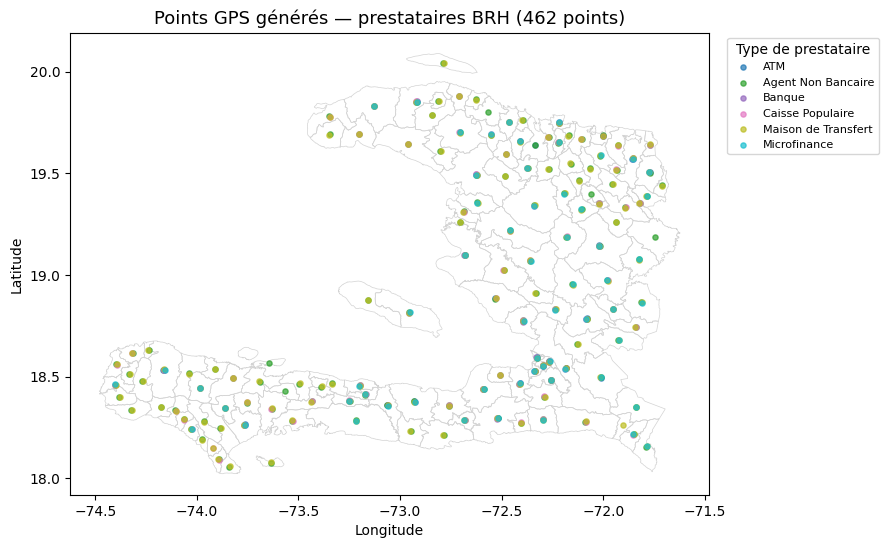

✅ Carte affichée — 462 points sur 140 communes


In [12]:
# ═══════════════════════════════════════════════════════════════════════════
#  SECTION 3D-BIS — CARTE DES POINTS GPS GÉNÉRÉS
#
#  Visualisation de contrôle : polygones communaux (hti_admin2.geojson)
#  + points GPS générés (gdf_brh_geo), colorés par type de prestataire.
# ═══════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt

print("=" * 65)
print("  SECTION 3D-BIS — CARTE DE CONTRÔLE DES POINTS GPS")
print("=" * 65)

fig, ax = plt.subplots(figsize=(9, 9))

# Fond de carte : limites des 140 communes
communes.boundary.plot(ax=ax, color="lightgrey", linewidth=0.5, zorder=1)

# Points GPS générés, colorés par type de prestataire
types_uniques = sorted(gdf_brh_geo["type_prestataire"].unique())
cmap = plt.get_cmap("tab10", len(types_uniques))

for i, type_presta in enumerate(types_uniques):
    subset = gdf_brh_geo[gdf_brh_geo["type_prestataire"] == type_presta]
    ax.scatter(
        subset["longitude"], subset["latitude"],
        s=14, alpha=0.7, color=cmap(i), label=type_presta, zorder=2,
    )

ax.set_title(f"Points GPS générés — prestataires BRH ({len(gdf_brh_geo)} points)", fontsize=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(title="Type de prestataire", loc="upper left", bbox_to_anchor=(1.02, 1), fontsize=8)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

print(f"✅ Carte affichée — {len(gdf_brh_geo)} points sur {communes['adm2_pcode'].nunique()} communes")


  SECTION 3D-TER — ZOOM DE VÉRIFICATION

📍 Saint-Marc — 6 points générés :


,type_prestataire,effectif,latitude,longitude
240,Maison de Transfert,77,19.096509,-72.682849
241,Agent Non Bancaire,79,19.097106,-72.681771
242,Banque,4,19.097714,-72.685085
243,ATM,3,19.096557,-72.682456
244,Microfinance,8,19.098598,-72.681867
245,Caisse Populaire,4,19.099091,-72.681089



✅ Écart max entre points : ≈ 444 m (cohérent avec le bruit ±330 m appliqué en Section 3D)


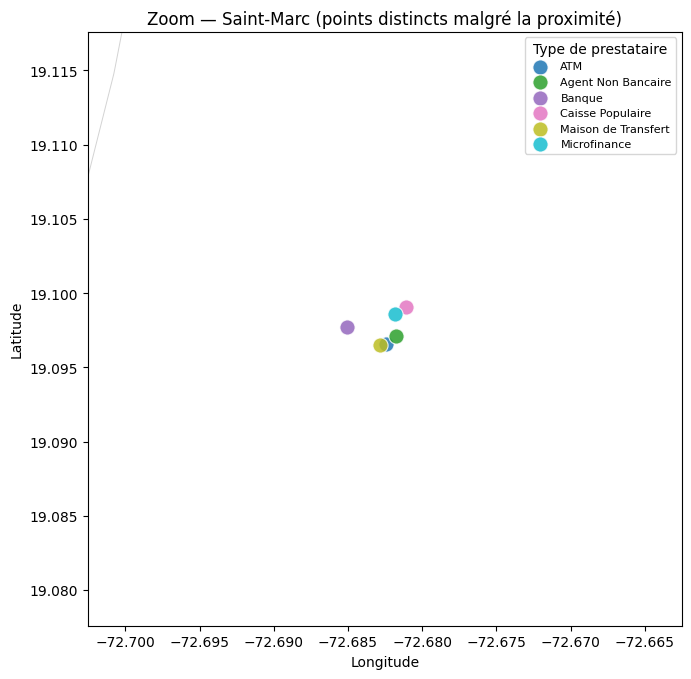

In [13]:
# ═══════════════════════════════════════════════════════════════════════════
#  SECTION 3D-TER — ZOOM DE VÉRIFICATION SUR UNE COMMUNE
#
#  À l'échelle nationale, le bruit GPS (±0.003° ≈ ±330 m) est invisible :
#  les points d'une même commune semblent superposés alors qu'ils sont bien
#  distincts. Cette cellule le prouve : tableau brut + carte zoomée.
# ═══════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("  SECTION 3D-TER — ZOOM DE VÉRIFICATION")
print("=" * 65)

# 👉 Change ce nom pour inspecter une autre commune
COMMUNE_ZOOM = "Saint-Marc"

pts_commune = gdf_brh_geo[
    gdf_brh_geo["nom_commune"].str.contains(COMMUNE_ZOOM, case=False, na=False)
].copy()

print(f"\n📍 {COMMUNE_ZOOM} — {len(pts_commune)} points générés :")
display(pts_commune[["type_prestataire", "effectif", "latitude", "longitude"]])

if len(pts_commune) > 1:
    ecart_max_m = (
        pts_commune[["latitude", "longitude"]].max()
        - pts_commune[["latitude", "longitude"]].min()
    ).abs().max() * 111_000  # ~111 km par degré
    print(f"\n✅ Écart max entre points : ≈ {ecart_max_m:.0f} m "
          f"(cohérent avec le bruit ±330 m appliqué en Section 3D)")

# --- Carte zoomée ---
fig, ax = plt.subplots(figsize=(7, 7))
communes.boundary.plot(ax=ax, color="lightgrey", linewidth=0.7, zorder=1)

for i, type_presta in enumerate(sorted(pts_commune["type_prestataire"].unique())):
    subset = pts_commune[pts_commune["type_prestataire"] == type_presta]
    ax.scatter(
        subset["longitude"], subset["latitude"],
        s=120, alpha=0.85, color=cmap(types_uniques.index(type_presta)),
        label=type_presta, zorder=3, edgecolor="white", linewidth=0.8,
    )

if len(pts_commune):
    lat_c, lon_c = pts_commune["latitude"].mean(), pts_commune["longitude"].mean()
    marge = 0.02  # ≈ 2.2 km autour du centre, pour bien voir l'écart de 330 m
    ax.set_xlim(lon_c - marge, lon_c + marge)
    ax.set_ylim(lat_c - marge, lat_c + marge)

ax.set_title(f"Zoom — {COMMUNE_ZOOM} (points distincts malgré la proximité)", fontsize=12)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.legend(title="Type de prestataire", loc="best", fontsize=8)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()


In [14]:
# ═══════════════════════════════════════════════════════════════════════════
#  SECTION 3E — EXPORT DU TABLEAU GÉOLOCALISÉ
# ═══════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("  SECTION 3E — EXPORT")
print("=" * 65)

pts_csv = gdf_brh_geo.drop(columns="geometry")
pts_csv.to_csv("G10_points_brh_geo.csv", index=False, encoding="utf-8-sig")
print(f"✅ G10_points_brh_geo.csv — {len(pts_csv)} lignes")

gdf_brh_geo.to_file("G10_points_brh_geo.geojson", driver="GeoJSON")
print("✅ G10_points_brh_geo.geojson")

if IN_COLAB:
    for fname in ["G10_points_brh_geo.csv", "G10_points_brh_geo.geojson"]:
        files.download(fname)


  SECTION 3E — EXPORT
✅ G10_points_brh_geo.csv — 462 lignes
✅ G10_points_brh_geo.geojson


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
# ═══════════════════════════════════════════════════════════════════════════
#  SECTION 3F — VARIABLE ACCÈS ROUTIER (proximité des points au réseau routier)
#
#  Approche retenue : proportion de points proches d'une route.
#  Pour chaque commune, on calcule le % de points BRH situés à moins de
#  SEUIL_ROUTE_M mètres d'une route OSM, puis on classe la commune en
#  Proche / Moyen / Éloigné selon ce pourcentage.
#
#  Routes récupérées via l'API Overpass (requête HTTP directe avec `requests`,
#  déjà installé en Section 0 — aucune nouvelle librairie ajoutée).
# ═══════════════════════════════════════════════════════════════════════════

import requests
from shapely.geometry import LineString

print("=" * 65)
print("  SECTION 3F — ACCÈS ROUTIER")
print("=" * 65)

SEUIL_ROUTE_M = 500      # seuil de proximité à une route (mètres), modifiable
SEUIL_PROCHE  = 0.66     # ≥ 66% des points proches d'une route  → "Proche"
SEUIL_MOYEN   = 0.33     # ≥ 33% (et < 66%)                      → "Moyen"
                          # < 33%                                  → "Éloigné"

# --- Téléchargement du réseau routier OSM d'Haïti via Overpass API ---
# Plusieurs miroirs testés dans l'ordre, avec User-Agent explicite
# (le serveur overpass-api.de renvoie parfois une erreur 406 sans cet en-tête)
HEADERS_OVERPASS = {"User-Agent": "G10-Capstone-UEH/1.0"}

OVERPASS_URLS = [
    "https://overpass-api.de/api/interpreter",
    "https://overpass.kumi.systems/api/interpreter",
    "https://overpass.openstreetmap.ru/api/interpreter",
]

OVERPASS_QUERY = """
[out:json][timeout:180];
area["ISO3166-1"="HT"][admin_level=2]->.haiti;
(
  way["highway"](area.haiti);
);
out geom;
"""

print("Téléchargement du réseau routier OSM (Overpass API)... (peut prendre 1-3 min)")

reponse = None
for url in OVERPASS_URLS:
    try:
        print(f"   Tentative sur {url} ...")
        reponse = requests.post(url, data={"data": OVERPASS_QUERY}, headers=HEADERS_OVERPASS, timeout=240)
        reponse.raise_for_status()
        print(f"   ✅ Succès via {url}")
        break
    except requests.exceptions.RequestException as e:
        print(f"   ❌ Échec sur {url} : {e}")
        reponse = None

if reponse is None:
    raise RuntimeError("Tous les serveurs Overpass ont échoué. Réessayez plus tard.")

data_osm = reponse.json()

lignes = []
for el in data_osm.get("elements", []):
    if el.get("type") == "way" and "geometry" in el:
        coords = [(pt["lon"], pt["lat"]) for pt in el["geometry"]]
        if len(coords) >= 2:
            lignes.append(LineString(coords))

routes_osm = gpd.GeoDataFrame(geometry=lignes, crs="EPSG:4326")
print(f"✅ {len(routes_osm)} segments routiers téléchargés")

# --- Projection en mètres (UTM 18N, adapté à Haïti) pour un calcul de distance exact ---
routes_proj = routes_osm.to_crs(epsg=32618)
points_proj = gdf_brh_geo.to_crs(epsg=32618).copy()

try:
    routes_union = routes_proj.geometry.union_all()      # geopandas récent
except AttributeError:
    routes_union = routes_proj.geometry.unary_union       # compatibilité versions plus anciennes

# --- Distance de chaque point BRH à la route la plus proche ---
points_proj["distance_route_m"] = points_proj.geometry.distance(routes_union)
points_proj["proche_route"]     = points_proj["distance_route_m"] <= SEUIL_ROUTE_M

# --- Agrégation par commune : % de points proches d'une route ---
df_acces_routier = (
    points_proj.groupby("id_commune")["proche_route"]
    .mean()
    .rename("pct_points_proches_route")
    .reset_index()
)

def classer_acces(pct):
    """Classe une commune selon la proportion de ses points BRH proches d'une route."""
    if pct >= SEUIL_PROCHE:
        return "Proche"
    elif pct >= SEUIL_MOYEN:
        return "Moyen"
    else:
        return "Éloigné"

df_acces_routier["acces_routier"] = df_acces_routier["pct_points_proches_route"].apply(classer_acces)
df_acces_routier["pct_points_proches_route"] = (df_acces_routier["pct_points_proches_route"] * 100).round(1)

print(f"\n✅ acces_routier calculée pour {len(df_acces_routier)} communes (seuil {SEUIL_ROUTE_M} m)")
print(df_acces_routier["acces_routier"].value_counts())
display(df_acces_routier.head(5))


  SECTION 3F — ACCÈS ROUTIER
Téléchargement du réseau routier OSM (Overpass API)... (peut prendre 1-3 min)
   Tentative sur https://overpass-api.de/api/interpreter ...
   ✅ Succès via https://overpass-api.de/api/interpreter
✅ 131296 segments routiers téléchargés

✅ acces_routier calculée pour 140 communes (seuil 500 m)
acces_routier
Proche     100
Éloigné     30
Moyen       10
Name: count, dtype: int64


,id_commune,pct_points_proches_route,acces_routier
0,C-001,100.0,Proche
1,C-002,100.0,Proche
2,C-003,100.0,Proche
3,C-004,100.0,Proche
4,C-005,100.0,Proche


---
## Section 4 — Jointure exacte BRH ↔ IHSI sur `id_commune` (Étape 3)

**Jointure**, pas fusion : `pd.merge(..., on='id_commune', how='inner', validate='1:1')`.
Comme les 140 `id_commune` sont identiques dans les deux fichiers (vérifié Section 2B),
cette jointure est exacte et sans perte — aucune correspondance de nom n'intervient ici.


In [16]:
# ═══════════════════════════════════════════════════════════════════════════
#  SECTION 4A — RÉSUMÉ BRH PAR COMMUNE (avant jointure)
# ═══════════════════════════════════════════════════════════════════════════

resume_brh = df_brh_agg.drop(columns=['norm', 'adm2_pcode']).copy()
resume_brh = resume_brh.rename(columns={
    t: "brh_" + t.lower().replace(' ', '_').replace('/', '_')
    for t in GROUPES_SERVICES
})
cols_brh_effectif = [c for c in resume_brh.columns if c.startswith('brh_')]
resume_brh['brh_total_effectif'] = resume_brh[cols_brh_effectif].sum(axis=1)

print("=" * 65)
print("  SECTION 4A — RÉSUMÉ BRH PAR COMMUNE")
print("=" * 65)
display(resume_brh.head(3))


  SECTION 4A — RÉSUMÉ BRH PAR COMMUNE


,id_commune,nom_commune,arrondissement,brh_maison_de_transfert,brh_agent_non_bancaire,brh_banque,brh_atm,brh_microfinance,brh_caisse_populaire,brh_total_effectif
0,C-001,Port-au-Prince,Port-au-Prince,139,248,22,30,16,6,461
1,C-002,Delmas,Port-au-Prince,168,184,25,37,8,2,424
2,C-003,Cité Soleil,Port-au-Prince,9,21,2,1,2,1,36


In [17]:
# ═══════════════════════════════════════════════════════════════════════════
#  SECTION 4B — JOINTURE EXACTE SUR id_commune
# ═══════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("  SECTION 4B — JOINTURE BRH ↔ IHSI SUR id_commune")
print("=" * 65)

# Colonnes IHSI redondantes avec resume_brh (déjà présentes côté BRH)
cols_ihsi_exclure = [c for c in ['nom_commune', 'arrondissement'] if c in df_ihsi.columns]

matrice_brh_ihsi = resume_brh.merge(
    df_ihsi.drop(columns=cols_ihsi_exclure),
    on='id_commune',
    how='inner',
    validate='1:1',      # échoue explicitement si la clé n'est pas 1-à-1
)

print(f"✅ Jointure exacte sur id_commune")
print(f"   {len(matrice_brh_ihsi)} communes × {len(matrice_brh_ihsi.columns)} colonnes")
assert len(matrice_brh_ihsi) == 140, "⚠️ La jointure n'a pas produit 140 communes"
display(matrice_brh_ihsi.head(3))


  SECTION 4B — JOINTURE BRH ↔ IHSI SUR id_commune
✅ Jointure exacte sur id_commune
   140 communes × 24 colonnes


,id_commune,nom_commune,arrondissement,brh_maison_de_transfert,brh_agent_non_bancaire,brh_banque,brh_atm,brh_microfinance,brh_caisse_populaire,brh_total_effectif,population_totale,population_urbaine,pop_masculine,pop_masculine_urbaine,pop_feminine,pop_feminine_urbaine,pop_masculine_18_plus,pop_masculine_18_plus_urbaine,pop_feminine_18_plus,pop_feminine_18_plus_urbaine,nb_menages,nb_menages_urbains,superficie_km2,superficie_urbaine_km2
0,C-001,Port-au-Prince,Port-au-Prince,139,248,22,30,16,6,461,989447,988438,468815,468450,520632,519988,322606,322364,358875,358458,213294,213077,36.04,25.29
1,C-002,Delmas,Port-au-Prince,168,184,25,37,8,2,424,396122,396122,188524,188524,207598,207598,125356,125356,134822,134822,83739,83739,27.74,27.74
2,C-003,Cité Soleil,Port-au-Prince,9,21,2,1,2,1,36,265687,265687,130716,130716,134971,134971,86918,86918,87653,87653,59435,59435,21.81,21.81


---
## Section 5 — Variables contextuelles WBG 2017 à 6 strates (Étape 4)

Version mise à jour : au lieu des **3 zones WBG** (PAP / Connectée / Non-connectée), les
variables sont maintenant calées sur les **6 strates** de l'enquête WBG (Tableau 6, colonne
« Strate »), qui croisent chaque zone avec le statut Urbain/Rural. C'est plus fin, et surtout
plus fidèle au plan d'échantillonnage réel de l'enquête — moins de bruit synthétique nécessaire.

### Construction de la strate

`strate = zone_wbg (PAP / Connectée (RN) / Non-connectée (H-Ile)) × urbain_rural`

- `zone_wbg` : classification communale reprise du script précédent (déjà validée par le
  superviseur).
- `urbain_rural` : dérivé **directement des données IHSI** — `population_urbaine /
  population_totale ≥ 50%` → `Urbain`, sinon `Rural`. Objectif et vérifiable (65/140 communes
  classées Urbain avec ce seuil), contrairement à une classification manuelle.

### Variables ajoutées/mises à jour

| Variable | Granularité | Source | Note |
|---|---|---|---|
| `strate` | 6 catégories | Dérivée (zone_wbg × urbain_rural) | — |
| `taux_compte_formel` | **6 strates** | Tableau 6, colonne Strate | ex. Rurale-PAP 47,9% / Urbaine-Non-connectée 23,6% |
| `taux_compte_mobile` | **6 strates** | Tableau 6, colonne Strate | ex. Rurale-PAP 31,0% / Urbaine-Connectée 3,0% |
| `taux_utilisation_OTA` | **6 strates** | Tableau 6, colonne Strate | ex. Rurale-Non-connectée 78,3% / Urbaine-PAP 55,0% |
| `score_connaissance_fka` | **6 strates** | Schéma 10, panels C/D | Score moyen de connaissance financière (échelle 0-8) |
| `taux_connaissance_banque` | 3 zones (héritée) | Tableau 7 | Pas de ventilation Urbain/Rural disponible dans la source |
| `taux_satisfaction_banque` | 3 zones (héritée) | Tableau 7 | Idem |
| `taux_epargne_formelle` | Urbain/Rural | Schéma 2 | Pas de ventilation par zone WBG disponible |
| `taux_endettement_formel` | Urbain/Rural | Schéma 9 | Idem |
| `taux_telephone_mobile` | Urbain/Rural | Schéma 29, panel B | Nouveau — proxy d'adoption mobile money |
| `taux_internet` | Urbain/Rural | Schéma 29, panel B | Nouveau — proxy finance digitale |

> ⚠️ **2 hypothèses à signaler dans le rapport :**
> 1. Le Tableau 6 liste une ligne « Non-connectée (H-Ile) » **sans préfixe Urbain/Rural**, à côté
>    d'une ligne « Rurale-Non-connectée (H-Ile) ». Par cohérence avec le Schéma 39 (qui distingue
>    bien Urbaine-Non-connectée et Rurale-Non-connectée), j'ai interprété la ligne ambiguë comme
>    **Urbaine-Non-connectée (H-Ile)**. À vérifier si vous avez le tableau source complet.
> 2. Le seuil `population_urbaine/population_totale ≥ 50%` pour définir Urbain/Rural est un choix
>    méthodologique — pas une valeur donnée par le WBG. Documentez-le comme tel.

Chaque valeur reçoit toujours un bruit gaussien (σ = 15 %, seed = 42) pour la variance intra-strate.


In [18]:
# ═══════════════════════════════════════════════════════════════════════════
#  SECTION 5A — CLASSIFICATION DES COMMUNES EN 6 STRATES WBG 2017
#
#  strate = zone_wbg (PAP / Connectée (RN) / Non-connectée (H-Ile))
#         × urbain_rural (dérivé de IHSI : population_urbaine/population_totale)
# ═══════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("  SECTION 5A — CLASSIFICATION EN 6 STRATES WBG")
print("=" * 65)

matrice = matrice_brh_ihsi.copy()

# ── Zone WBG (reprise du découpage validé précédemment) ──────────────────
COMMUNES_PAP = {
    "Port-au-Prince", "Delmas", "Pétion-Ville", "Carrefour",
    "Tabarre", "Cité Soleil", "Croix-des-Bouquets",
}

COMMUNES_CONNECTEES = {
    "Cap-Haïtien", "Quartier-Morin", "Limonade", "Plaine-du-Nord", "Milot",
    "Ouanaminthe", "Trou-du-Nord", "Fort-Liberté",
    "Gonaïves", "Saint-Marc", "Verrettes", "Dessalines", "Hinche", "Mirebalais",
    "Les Cayes", "Jacmel", "Jérémie", "Miragoâne", "Aquin",
    "Léogâne", "Arcahaie", "Cabaret", "Kenscoff",
    "Anse-à-Veau", "Corail",
}

def classer_zone_wbg(nom_commune):
    """Classe une commune dans l'une des 3 zones WBG 2017."""
    if nom_commune in COMMUNES_PAP:
        return "PAP"
    if nom_commune in COMMUNES_CONNECTEES:
        return "Connectée (RN)"
    return "Non-connectée (H-Ile)"

matrice['zone_wbg'] = matrice['nom_commune'].apply(classer_zone_wbg)

# ── Urbain/Rural dérivé de IHSI (seuil 50%, objectif et vérifiable) ───────
SEUIL_URBAIN = 0.50
matrice['part_urbaine'] = matrice['population_urbaine'] / matrice['population_totale']
matrice['urbain_rural'] = np.where(matrice['part_urbaine'] >= SEUIL_URBAIN, 'Urbain', 'Rural')

# ── Strate = croisement des deux ──────────────────────────────────────────
matrice['strate'] = np.where(
    matrice['urbain_rural'] == 'Urbain',
    'Urbaine-' + matrice['zone_wbg'],
    'Rurale-' + matrice['zone_wbg'],
)

print(f"\n   ✅ zone_wbg :")
print(matrice['zone_wbg'].value_counts().to_string())
print(f"\n   ✅ urbain_rural (seuil {SEUIL_URBAIN:.0%}) :")
print(matrice['urbain_rural'].value_counts().to_string())
print(f"\n   ✅ strate (6 catégories) :")
print(matrice['strate'].value_counts().to_string())


  SECTION 5A — CLASSIFICATION EN 6 STRATES WBG

   ✅ zone_wbg :
zone_wbg
Non-connectée (H-Ile)    108
Connectée (RN)            25
PAP                        7

   ✅ urbain_rural (seuil 50%) :
urbain_rural
Rural     75
Urbain    65

   ✅ strate (6 catégories) :
strate
Rurale-Non-connectée (H-Ile)     68
Urbaine-Non-connectée (H-Ile)    40
Urbaine-Connectée (RN)           18
Urbaine-PAP                       7
Rurale-Connectée (RN)             7


In [19]:
# ═══════════════════════════════════════════════════════════════════════════
#  SECTION 5B — VALEURS WBG 2017 (lues dans les captures fournies)
#
#  3 granularités différentes selon la richesse de la source :
#    - PAR STRATE (6)      : compte_formel, compte_mobile, OTA, score FKA
#    - PAR ZONE WBG (3)    : connaissance_banque, satisfaction_banque
#    - PAR URBAIN/RURAL (2): epargne, endettement, telephone_mobile, internet
# ═══════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("  SECTION 5B — TABLES DE RÉFÉRENCE WBG 2017")
print("=" * 65)

# ── Variables par STRATE (Tableau 6, colonne Strate ; Schéma 10 C/D) ──────
WBG_COMPTE_FORMEL_STRATE = {
    "Rurale-PAP": 47.9, "Urbaine-PAP": 21.4,
    "Rurale-Connectée (RN)": 31.8, "Urbaine-Connectée (RN)": 13.8,
    "Rurale-Non-connectée (H-Ile)": 24.0, "Urbaine-Non-connectée (H-Ile)": 23.6,
}
WBG_COMPTE_MOBILE_STRATE = {
    "Rurale-PAP": 31.0, "Urbaine-PAP": 7.7,
    "Rurale-Connectée (RN)": 19.7, "Urbaine-Connectée (RN)": 3.0,
    "Rurale-Non-connectée (H-Ile)": 11.8, "Urbaine-Non-connectée (H-Ile)": 8.1,
}
WBG_OTA_STRATE = {
    "Rurale-PAP": 84.9, "Urbaine-PAP": 55.0,
    "Rurale-Connectée (RN)": 77.9, "Urbaine-Connectée (RN)": 49.6,
    "Rurale-Non-connectée (H-Ile)": 78.3, "Urbaine-Non-connectée (H-Ile)": 57.8,
}
WBG_FKA_STRATE = {
    "Rurale-PAP": 3.79, "Urbaine-PAP": 4.63,
    "Rurale-Connectée (RN)": 3.87, "Urbaine-Connectée (RN)": 4.13,
    "Rurale-Non-connectée (H-Ile)": 3.55, "Urbaine-Non-connectée (H-Ile)": 3.80,
}

# ── Variables par ZONE WBG (Tableau 7 — pas de ventilation Urbain/Rural) ──
WBG_CONNAISSANCE_ZONE = {"PAP": 98.0, "Connectée (RN)": 94.0, "Non-connectée (H-Ile)": 93.0}
WBG_SATISFACTION_ZONE = {"PAP": 65.0, "Connectée (RN)": 67.0, "Non-connectée (H-Ile)": 72.0}

# ── Variables par URBAIN/RURAL (Schémas 2, 9, 29 — pas de ventilation par zone) ──
WBG_EPARGNE_UR         = {"Urbain": 15.0, "Rural": 3.0}   # Schéma 2
WBG_ENDETTEMENT_UR     = {"Urbain": 11.0, "Rural": 3.0}   # Schéma 9
WBG_TELEPHONE_UR       = {"Urbain": 84.0, "Rural": 70.0}  # Schéma 29 (panel B)
WBG_INTERNET_UR        = {"Urbain": 42.0, "Rural": 11.0}  # Schéma 29 (panel B)

VARIABLES_PAR_STRATE = {
    "taux_compte_formel":       WBG_COMPTE_FORMEL_STRATE,
    "taux_compte_mobile":       WBG_COMPTE_MOBILE_STRATE,
    "taux_utilisation_OTA":     WBG_OTA_STRATE,
    "score_connaissance_fka":   WBG_FKA_STRATE,
}
VARIABLES_PAR_ZONE = {
    "taux_connaissance_banque": WBG_CONNAISSANCE_ZONE,
    "taux_satisfaction_banque": WBG_SATISFACTION_ZONE,
}
VARIABLES_PAR_UR = {
    "taux_epargne_formelle":    WBG_EPARGNE_UR,
    "taux_endettement_formel":  WBG_ENDETTEMENT_UR,
    "taux_telephone_mobile":    WBG_TELEPHONE_UR,
    "taux_internet":            WBG_INTERNET_UR,
}

print("   Variables par strate (6)      :", list(VARIABLES_PAR_STRATE.keys()))
print("   Variables par zone WBG (3)    :", list(VARIABLES_PAR_ZONE.keys()))
print("   Variables par urbain/rural (2):", list(VARIABLES_PAR_UR.keys()))


  SECTION 5B — TABLES DE RÉFÉRENCE WBG 2017
   Variables par strate (6)      : ['taux_compte_formel', 'taux_compte_mobile', 'taux_utilisation_OTA', 'score_connaissance_fka']
   Variables par zone WBG (3)    : ['taux_connaissance_banque', 'taux_satisfaction_banque']
   Variables par urbain/rural (2): ['taux_epargne_formelle', 'taux_endettement_formel', 'taux_telephone_mobile', 'taux_internet']


In [20]:
# ═══════════════════════════════════════════════════════════════════════════
#  SECTION 5C — APPLICATION DES VARIABLES WBG (avec bruit intra-groupe calibré)
#
#  Chaque commune reçoit la valeur de son strate/zone/urbain-rural + un bruit
#  gaussien (σ = 15 % de la valeur) pour introduire une variance réaliste —
#  sans quoi les communes d'un même groupe seraient strictement identiques.
# ═══════════════════════════════════════════════════════════════════════════

SIGMA_PCT = 0.15

def appliquer_wbg(valeur_zone, sigma_pct=SIGMA_PCT, borne_min=0.0, borne_max=100.0):
    bruit = rng.normal(loc=0.0, scale=sigma_pct * valeur_zone)
    return float(np.clip(valeur_zone + bruit, borne_min, borne_max))

print("=" * 65)
print("  SECTION 5C — APPLICATION AVEC BRUIT CALIBRÉ")
print("=" * 65)

for nom_var, table in VARIABLES_PAR_STRATE.items():
    matrice[nom_var] = matrice['strate'].map(table).apply(appliquer_wbg).round(2)

for nom_var, table in VARIABLES_PAR_ZONE.items():
    matrice[nom_var] = matrice['zone_wbg'].map(table).apply(appliquer_wbg).round(2)

for nom_var, table in VARIABLES_PAR_UR.items():
    matrice[nom_var] = matrice['urbain_rural'].map(table).apply(appliquer_wbg).round(2)

cols_wbg_toutes = (
    list(VARIABLES_PAR_STRATE) + list(VARIABLES_PAR_ZONE) + list(VARIABLES_PAR_UR)
)

print(f"✅ {len(cols_wbg_toutes)} variables WBG ajoutées : {cols_wbg_toutes}")
display(matrice[['id_commune', 'nom_commune', 'strate'] + cols_wbg_toutes].head(8))

print("\n   Moyenne par strate (contrôle de cohérence avec les valeurs sources) :")
display(matrice.groupby('strate')[list(VARIABLES_PAR_STRATE)].mean().round(1))


  SECTION 5C — APPLICATION AVEC BRUIT CALIBRÉ
✅ 10 variables WBG ajoutées : ['taux_compte_formel', 'taux_compte_mobile', 'taux_utilisation_OTA', 'score_connaissance_fka', 'taux_connaissance_banque', 'taux_satisfaction_banque', 'taux_epargne_formelle', 'taux_endettement_formel', 'taux_telephone_mobile', 'taux_internet']


,id_commune,nom_commune,strate,taux_compte_formel,taux_compte_mobile,taux_utilisation_OTA,score_connaissance_fka,taux_connaissance_banque,taux_satisfaction_banque,taux_epargne_formelle,taux_endettement_formel,taux_telephone_mobile,taux_internet
0,C-001,Port-au-Prince,Urbaine-PAP,20.40,7.09,54.30,5.02,100.00,68.69,13.84,9.24,100.00,43.41
1,C-002,Delmas,Urbaine-PAP,24.77,7.70,41.80,5.91,96.32,69.41,17.06,7.98,86.01,45.79
2,C-003,Cité Soleil,Urbaine-PAP,19.23,8.84,48.71,4.49,100.00,68.13,11.92,12.20,83.65,44.09
3,C-004,Tabarre,Urbaine-PAP,18.63,7.06,56.23,4.89,99.33,67.33,14.57,13.98,75.68,36.90
4,C-005,Carrefour,Urbaine-PAP,22.94,8.63,58.02,3.60,100.00,80.38,13.16,13.35,91.33,46.27
5,C-006,Pétion-Ville,Urbaine-PAP,16.47,8.48,58.44,5.46,100.00,54.59,15.25,8.32,90.01,37.31
6,C-007,Kenscoff,Urbaine-Connectée (RN),14.61,2.57,39.78,3.66,100.00,66.45,14.13,12.20,84.18,38.71
7,C-008,Gressier,Urbaine-Non-connectée (H-Ile),23.96,9.28,65.21,3.48,82.89,84.23,18.32,13.35,74.05,36.05



   Moyenne par strate (contrôle de cohérence avec les valeurs sources) :


,taux_compte_formel,taux_compte_mobile,taux_utilisation_OTA,score_connaissance_fka
strate,,,,
Rurale-Connectée (RN),33.6,20.3,81.8,4.3
Rurale-Non-connectée (H-Ile),24.0,11.7,77.0,3.6
Urbaine-Connectée (RN),13.4,2.9,51.5,4.1
Urbaine-Non-connectée (H-Ile),24.1,8.4,56.1,3.7
Urbaine-PAP,21.5,7.8,51.6,5.0


In [21]:
# ═══════════════════════════════════════════════════════════════════════════
#  SECTION 5D — FUSION DE LA VARIABLE ACCÈS ROUTIER DANS LA MATRICE
# ═══════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("  SECTION 5D — FUSION acces_routier")
print("=" * 65)

matrice = matrice.merge(
    df_acces_routier[["id_commune", "acces_routier"]],
    on="id_commune",
    how="left",
)
n_manquants = matrice["acces_routier"].isna().sum()
matrice["acces_routier"] = matrice["acces_routier"].fillna("Non déterminé")

print(f"✅ acces_routier ajoutée à la matrice ({n_manquants} commune(s) sans point BRH → \"Non déterminé\")")
cols_apercu = [c for c in ["id_commune", "nom_commune", "acces_routier"] if c in matrice.columns]
display(matrice[cols_apercu].head(5))


  SECTION 5D — FUSION acces_routier
✅ acces_routier ajoutée à la matrice (0 commune(s) sans point BRH → "Non déterminé")


,id_commune,nom_commune,acces_routier
0,C-001,Port-au-Prince,Proche
1,C-002,Delmas,Proche
2,C-003,Cité Soleil,Proche
3,C-004,Tabarre,Proche
4,C-005,Carrefour,Proche


---
### Section 5E — Variables qualitatives pour l'AFCM

L'AFCM (Analyse Factorielle des Correspondances Multiples) travaille sur des **variables
catégorielles**, pas continues. Cette section discrétise certaines variables numériques déjà
présentes dans `matrice` en classes interprétables, et ajoute les catégories déjà disponibles
(`strate`, `zone_wbg`, `urbain_rural`, `acces_routier`) à la liste des variables actives.

> ⚠️ Les noms de colonnes ci-dessous sont ceux **réellement présents dans cette matrice**
> (`population_totale`, `superficie_km2`, `brh_total_effectif`…) — pas ceux d'un exemple
> générique (`pop_urbaine`, `superficie_commune`, `dist_route_m`…), pour éviter tout `KeyError`.

| Variable qualitative | Construction | Classes |
|---|---|---|
| `classe_urbanisation` | `part_urbaine` (Section 5A) découpé en 3 | Rurale / Mi-urbaine / Urbaine |
| `classe_densite_demographique` | `population_totale / superficie_km2`, tertiles | Faible / Moyenne / Élevée |
| `classe_densite_bancaire` | `brh_total_effectif` pour 10 000 hab., tertiles | Faible / Moyenne / Élevée |
| `classe_diversite_services` | Nombre de types de services BRH présents (sur 6) | Faible / Moyenne / Élevée |
| `strate`, `zone_wbg`, `urbain_rural` | déjà créées (Section 5A) | — |
| `acces_routier` | déjà créée (Section 3F/5D, via Overpass) | Proche / Moyen / Éloigné |


In [22]:
# ═══════════════════════════════════════════════════════════════════════════
#  SECTION 5E — VARIABLES QUALITATIVES POUR L'AFCM
# ═══════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("  SECTION 5E — VARIABLES QUALITATIVES POUR L'AFCM")
print("=" * 65)

# ── 1. classe_urbanisation (3 classes, plus fin que urbain_rural binaire) ──
matrice['classe_urbanisation'] = pd.cut(
    matrice['part_urbaine'] * 100,
    bins=[-0.01, 30, 70, 100],
    labels=['Rurale', 'Mi-urbaine', 'Urbaine'],
)

# ── 2. classe_densite_demographique (tertiles, hab/km²) ────────────────────
matrice['densite_hab_km2'] = matrice['population_totale'] / matrice['superficie_km2']
matrice['classe_densite_demographique'] = pd.qcut(
    matrice['densite_hab_km2'], q=3, labels=['Faible', 'Moyenne', 'Élevée'], duplicates='drop',
)

# ── 3. classe_densite_bancaire (tertiles, effectif BRH pour 10 000 hab.) ───
matrice['densite_bancaire_10k'] = matrice['brh_total_effectif'] / (matrice['population_totale'] / 10_000)
matrice['classe_densite_bancaire'] = pd.qcut(
    matrice['densite_bancaire_10k'], q=3, labels=['Faible', 'Moyenne', 'Élevée'], duplicates='drop',
)

# ── 4. classe_diversite_services (nb de types de services BRH présents) ───
cols_types_service = [
    c for c in ['brh_maison_de_transfert', 'brh_agent_non_bancaire', 'brh_banque',
                'brh_atm', 'brh_microfinance', 'brh_caisse_populaire']
    if c in matrice.columns
]
matrice['nb_types_services'] = (matrice[cols_types_service] > 0).sum(axis=1)
matrice['classe_diversite_services'] = pd.cut(
    matrice['nb_types_services'],
    bins=[-1, 1, 3, len(cols_types_service)],
    labels=['Faible', 'Moyenne', 'Élevée'],
)

print("   ✅ classe_urbanisation :")
print(matrice['classe_urbanisation'].value_counts().to_string())
print("\n   ✅ classe_densite_demographique :")
print(matrice['classe_densite_demographique'].value_counts().to_string())
print("\n   ✅ classe_densite_bancaire :")
print(matrice['classe_densite_bancaire'].value_counts().to_string())
print("\n   ✅ classe_diversite_services (sur {} types de services) :".format(len(cols_types_service)))
print(matrice['classe_diversite_services'].value_counts().to_string())

cols_quali_derivees = [
    'classe_urbanisation', 'classe_densite_demographique',
    'classe_densite_bancaire', 'classe_diversite_services',
]
display(matrice[['id_commune', 'nom_commune', 'strate', 'acces_routier'] + cols_quali_derivees].head(8))


  SECTION 5E — VARIABLES QUALITATIVES POUR L'AFCM
   ✅ classe_urbanisation :
classe_urbanisation
Mi-urbaine    64
Urbaine       40
Rurale        36

   ✅ classe_densite_demographique :
classe_densite_demographique
Faible     47
Élevée     47
Moyenne    46

   ✅ classe_densite_bancaire :
classe_densite_bancaire
Faible     47
Élevée     47
Moyenne    46

   ✅ classe_diversite_services (sur 6 types de services) :
classe_diversite_services
Moyenne    83
Élevée     51
Faible      6


,id_commune,nom_commune,strate,acces_routier,classe_urbanisation,classe_densite_demographique,classe_densite_bancaire,classe_diversite_services
0,C-001,Port-au-Prince,Urbaine-PAP,Proche,Urbaine,Élevée,Élevée,Élevée
1,C-002,Delmas,Urbaine-PAP,Proche,Urbaine,Élevée,Élevée,Élevée
2,C-003,Cité Soleil,Urbaine-PAP,Proche,Urbaine,Élevée,Faible,Élevée
3,C-004,Tabarre,Urbaine-PAP,Proche,Urbaine,Élevée,Élevée,Élevée
4,C-005,Carrefour,Urbaine-PAP,Proche,Urbaine,Élevée,Élevée,Élevée
5,C-006,Pétion-Ville,Urbaine-PAP,Proche,Urbaine,Élevée,Élevée,Élevée
6,C-007,Kenscoff,Urbaine-Connectée (RN),Proche,Urbaine,Moyenne,Moyenne,Moyenne
7,C-008,Gressier,Urbaine-Non-connectée (H-Ile),Proche,Urbaine,Moyenne,Élevée,Moyenne


---
### Section 5F — Pauvreté et privation spatiale (proxy BID 2014)

Ajout de 3 variables construites à partir d'un jeu de données couvrant les **140 communes**,
reconstruit à partir de la carte du rapport *"Vers une réponse aux crises récurrentes et à la
fragilité chronique"* (Groupe de la Banque Mondiale, 2022 — lui-même basé sur la carte de
pauvreté BID/Pokhriyal et al. 2014).

> ⚠️ **Ce sont des variables proxy, pas des valeurs officielles** — reconstruites par lecture
> visuelle d'une carte à quantiles, comme documenté dans le fichier source lui-même
> (`Description_variables`). À signaler explicitement dans le rapport comme des estimations
> approximatives, pas des statistiques IHSI/BID certifiées.

| Variable | Description | Échelle |
|---|---|---|
| `taux_pauvrete_proxy` | Taux de pauvreté communal estimé (proxy, carte BID 2014) | % |
| `indice_privation_spatiale` | Indice composite de privation spatiale (accès services/infrastructures) | 0 (faible) à 1 (forte) |
| `departement` | Département administratif de la commune | Ouest / Nord / Sud / Artibonite / Nord-Est / Grand'Anse / Centre / Nippes / Nord-Ouest / Sud-Est |
| `classe_privation_spatiale` | Version qualitative (tertiles) de `indice_privation_spatiale` | Faible / Moyenne / Élevée |

**Jointure sur `id_commune`** (le fichier a été mis à jour pour inclure cette clé, format
`C-001`…`C-140`, identique à BRH/IHSI) : `merge(..., on='id_commune', how='inner',
validate='1:1')` — jointure exacte, plus de correspondance de nom nécessaire pour ce fichier.


In [24]:
# ═══════════════════════════════════════════════════════════════════════════
#  SECTION 5F — POINTS DE PAUVRETÉ ET PRIVATION SPATIALE (PROXY BID 2014)
#  Jointure EXACTE sur id_commune (le fichier proxy contient désormais cette clé)
# ═══════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("  SECTION 5F — PAUVRETÉ / PRIVATION SPATIALE (PROXY)")
print("=" * 65)

CHEMIN_PAUVRETE_PROXY = f"{DOSSIER_DATA}/base_communes_proxy_pauvrete_privation.xlsx"

df_pauvrete = pd.read_excel(CHEMIN_PAUVRETE_PROXY, sheet_name="Sheet")
df_pauvrete = df_pauvrete.rename(columns={"pauvrete": "taux_pauvrete_proxy"})
df_pauvrete['id_commune'] = df_pauvrete['id_commune'].astype(str).str.strip()

# Colonnes déjà présentes côté matrice (évite les doublons _x/_y au merge)
cols_deja_presentes = [c for c in ['commune', 'nom_commune'] if c in df_pauvrete.columns]
df_pauvrete_join = df_pauvrete.drop(columns=cols_deja_presentes)

matrice = matrice.merge(
    df_pauvrete_join,
    on='id_commune',
    how='inner',
    validate='1:1',   # échoue explicitement si la clé n'est pas 1-à-1
)

print(f"✅ Jointure exacte sur id_commune : {len(matrice)}/140 communes")
assert len(matrice) == 140, "⚠️ La jointure n'a pas produit 140 communes"

display(matrice[['id_commune', 'nom_commune', 'departement', 'taux_pauvrete_proxy', 'indice_privation_spatiale']].head(8))
print("\n   Statistiques (contrôle de cohérence) :")
display(matrice[['taux_pauvrete_proxy', 'indice_privation_spatiale']].describe().round(3))

# ── Version qualitative de l'indice de privation spatiale (pour l'AFCM) ──
matrice['classe_privation_spatiale'] = pd.qcut(
    matrice['indice_privation_spatiale'], q=3,
    labels=['Faible', 'Moyenne', 'Élevée'], duplicates='drop',
)
print("\n   ✅ classe_privation_spatiale (tertiles) :")
print(matrice['classe_privation_spatiale'].value_counts().to_string())


  SECTION 5F — PAUVRETÉ / PRIVATION SPATIALE (PROXY)
✅ Jointure exacte sur id_commune : 140/140 communes


,id_commune,nom_commune,departement,taux_pauvrete_proxy,indice_privation_spatiale
0,C-001,Port-au-Prince,Ouest,44.2,0.276
1,C-002,Delmas,Ouest,56.4,0.492
2,C-003,Cité Soleil,Ouest,74.7,0.930
3,C-004,Tabarre,Ouest,63.7,0.657
4,C-005,Carrefour,Ouest,45.4,0.241
5,C-006,Pétion-Ville,Ouest,53.8,0.432
6,C-007,Kenscoff,Ouest,78.6,0.895
7,C-008,Gressier,Ouest,63.6,0.680



   Statistiques (contrôle de cohérence) :


,taux_pauvrete_proxy,indice_privation_spatiale
count,140.000,140.000
mean,59.731,0.556
std,10.474,0.244
min,42.000,0.156
25%,51.500,0.357
50%,59.100,0.534
75%,67.950,0.752
max,78.600,0.994



   ✅ classe_privation_spatiale (tertiles) :
classe_privation_spatiale
Faible     47
Élevée     47
Moyenne    46


---
### Section 5G — Variables qualitatives supplémentaires (robustesse AFCM)

5 nouvelles variables catégorielles, choisies pour couvrir des dimensions **non redondantes**
avec `strate`/`zone_wbg`/`urbain_rural`/`classe_urbanisation`.

| Variable | Construction | Modalités |
|---|---|---|
| `classe_taille_population` | Tertiles sur `population_totale` | Petite / Moyenne / Grande |
| `classe_pauvrete` | Tertiles sur `taux_pauvrete_proxy` | Faible / Moyenne / Élevée |
| `a_une_banque` | `brh_banque > 0` | Oui / Non |
| `profil_services_financiers` | Typologie hiérarchique construite à partir des données BRH brutes (voir note) | 5 modalités |
| `classe_taille_menage` | Tertiles sur `population_totale / nb_menages` | Petite / Moyenne / Grande |

**`profil_services_financiers` — pourquoi pas un simple "type dominant" ?**

Un premier essai (`type_prestataire_dominant` = type BRH ayant l'effectif le plus élevé par
commune) s'est révélé **quasi dégénéré** : MonCash est présent dans 138/140 communes avec des
effectifs très supérieurs aux autres services (agents informels très nombreux), donc l'argmax
retombait presque toujours sur MonCash ou Maison de Transfert — seulement 2 modalités actives
sur 6 possibles, aucun pouvoir discriminant réel.

À la place, `profil_services_financiers` classe chaque commune selon la **présence
d'institutions financières formelles** (Banque, ATM, Microfinance, Caisse Populaire — pas le
volume d'agents informels), avec une règle hiérarchique appliquée directement sur les données
BRH brutes :

1. **Pôle financier complet** — Banque **ET** ATM **ET** Microfinance présents
2. **Bancarisé** — Banque présente (sans être un pôle complet)
3. **Microfinance sans banque** — Microfinance présente, pas de Banque
4. **Caisse populaire uniquement** — seule institution formelle présente
5. **Aucune institution formelle** — ni Banque, ni ATM, ni Microfinance, ni Caisse Populaire
   (peut tout de même avoir MonCash/Maison de Transfert, non formels au sens BRH)

Répartition obtenue (vérifiée sur les 140 communes) : Aucune institution formelle (46) /
Microfinance sans banque (34) / Caisse populaire uniquement (33) / Pôle financier complet (22)
/ Bancarisé (5) — 5 catégories toutes représentées, bien plus informatif pour l'AFCM.


In [25]:
# ═══════════════════════════════════════════════════════════════════════════
#  SECTION 5G — VARIABLES QUALITATIVES SUPPLÉMENTAIRES (ROBUSTESSE AFCM)
# ═══════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("  SECTION 5G — VARIABLES QUALITATIVES SUPPLÉMENTAIRES")
print("=" * 65)

# ── 1. classe_taille_population (tertiles) ─────────────────────────────────
matrice['classe_taille_population'] = pd.qcut(
    matrice['population_totale'], q=3, labels=['Petite', 'Moyenne', 'Grande'], duplicates='drop',
)

# ── 2. classe_pauvrete (tertiles sur taux_pauvrete_proxy) ───────────────────
matrice['classe_pauvrete'] = pd.qcut(
    matrice['taux_pauvrete_proxy'], q=3, labels=['Faible', 'Moyenne', 'Élevée'], duplicates='drop',
)

# ── 3. a_une_banque (présence/absence, seuil structurel) ───────────────────
matrice['a_une_banque'] = np.where(matrice['brh_banque'] > 0, 'Oui', 'Non')

# ── 4. profil_services_financiers (typologie hiérarchique, données BRH brutes) ─
#  Construite sur la PRÉSENCE d'institutions formelles (pas le volume d'agents
#  informels MonCash/Transfert, qui écraserait toute variance — cf. note markdown)
a_banque_formel       = matrice['brh_banque'] > 0
a_atm_formel          = matrice['brh_atm'] > 0
a_microfinance_formel = matrice['brh_microfinance'] > 0
a_caissepop_formel    = matrice['brh_caisse_populaire'] > 0

def classer_profil_services(i):
    """Classe une commune selon la présence d'institutions financières formelles
    (Banque, ATM, Microfinance, Caisse Populaire) — pas le volume d'agents informels."""
    if a_banque_formel[i] and a_atm_formel[i] and a_microfinance_formel[i]:
        return 'Pôle financier complet'
    if a_banque_formel[i]:
        return 'Bancarisé'
    if a_microfinance_formel[i]:
        return 'Microfinance sans banque'
    if a_caissepop_formel[i]:
        return 'Caisse populaire uniquement'
    return 'Aucune institution formelle'

matrice['profil_services_financiers'] = [classer_profil_services(i) for i in matrice.index]

# ── 5. classe_taille_menage (tertiles, population/ménages) ──────────────────
matrice['taille_moyenne_menage'] = matrice['population_totale'] / matrice['nb_menages']
matrice['classe_taille_menage'] = pd.qcut(
    matrice['taille_moyenne_menage'], q=3, labels=['Petite', 'Moyenne', 'Grande'], duplicates='drop',
)

print("   ✅ classe_taille_population :")
print(matrice['classe_taille_population'].value_counts().to_string())
print("\n   ✅ classe_pauvrete :")
print(matrice['classe_pauvrete'].value_counts().to_string())
print("\n   ✅ a_une_banque :")
print(matrice['a_une_banque'].value_counts().to_string())
print("\n   ✅ profil_services_financiers :")
print(matrice['profil_services_financiers'].value_counts().to_string())
print("\n   ✅ classe_taille_menage :")
print(matrice['classe_taille_menage'].value_counts().to_string())

cols_quali_supp = [
    'classe_taille_population', 'classe_pauvrete', 'a_une_banque',
    'profil_services_financiers', 'classe_taille_menage',
]
display(matrice[['id_commune', 'nom_commune'] + cols_quali_supp].head(8))


  SECTION 5G — VARIABLES QUALITATIVES SUPPLÉMENTAIRES
   ✅ classe_taille_population :
classe_taille_population
Petite     47
Grande     47
Moyenne    46

   ✅ classe_pauvrete :
classe_pauvrete
Faible     47
Élevée     47
Moyenne    46

   ✅ a_une_banque :
a_une_banque
Non    113
Oui     27

   ✅ profil_services_financiers :
profil_services_financiers
Aucune institution formelle    46
Microfinance sans banque       34
Caisse populaire uniquement    33
Pôle financier complet         22
Bancarisé                       5

   ✅ classe_taille_menage :
classe_taille_menage
Petite     47
Grande     47
Moyenne    46


,id_commune,nom_commune,classe_taille_population,classe_pauvrete,a_une_banque,profil_services_financiers,classe_taille_menage
0,C-001,Port-au-Prince,Grande,Faible,Oui,Pôle financier complet,Moyenne
1,C-002,Delmas,Grande,Moyenne,Oui,Pôle financier complet,Moyenne
2,C-003,Cité Soleil,Grande,Élevée,Oui,Pôle financier complet,Moyenne
3,C-004,Tabarre,Grande,Moyenne,Oui,Pôle financier complet,Moyenne
4,C-005,Carrefour,Grande,Faible,Oui,Pôle financier complet,Grande
5,C-006,Pétion-Ville,Grande,Moyenne,Oui,Pôle financier complet,Moyenne
6,C-007,Kenscoff,Moyenne,Élevée,Non,Caisse populaire uniquement,Petite
7,C-008,Gressier,Petite,Moyenne,Non,Caisse populaire uniquement,Petite


---
### Section 5H — Préparation pour l'AFCM (variables actives vs supplémentaires)

Avec 15 variables qualitatives au total, plusieurs se recouvrent fortement (ex. `zone_wbg`,
`urbain_rural`, `strate`, `classe_urbanisation` capturent toutes la même information de base).
Les mettre **toutes en actives** ferait dominer les premiers axes par cette seule répétition,
au détriment de dimensions réellement nouvelles (profil de services, pauvreté, taille de
ménage…).

`prince.MCA` permet de distinguer :
- **Variables actives** : construisent les axes factoriels.
- **Variables supplémentaires (illustratives)** : projetées sur les axes après coup, sans
  influencer leur construction — utiles pour l'interprétation, sans polluer le calcul.

### Sélection proposée

| Actives (construisent les axes) | Supplémentaires (projetées après coup) |
|---|---|
| `strate` | `zone_wbg` |
| `classe_densite_bancaire` | `urbain_rural` |
| `classe_diversite_services` | `classe_urbanisation` |
| `classe_taille_population` | `classe_densite_demographique` |
| `classe_privation_spatiale` | `classe_pauvrete` |
| `acces_routier` | `a_une_banque` |
| `classe_taille_menage` | `departement` |
| `profil_services_financiers` | |

> `classe_privation_spatiale` est gardée active plutôt que `classe_pauvrete` (les deux sont
> proches) car elle synthétise plusieurs dimensions (accès, infrastructures), pas seulement le
> revenu. `departement` est mis en supplémentaire car ses 10 modalités (dont certaines rares)
> risqueraient de dominer artificiellement les axes en variable active.

Ajustez cette répartition selon vos propres résultats de contribution/inertie une fois l'ACM
tournée — c'est un point de départ raisonné, pas une vérité figée.


In [27]:
# ═══════════════════════════════════════════════════════════════════════════
#  SECTION 5H — PRÉPARATION AFCM : VARIABLES ACTIVES VS SUPPLÉMENTAIRES
# ═══════════════════════════════════════════════════════════════════════════

!pip install prince -q

import prince

print("=" * 65)
print("  SECTION 5H — PRÉPARATION AFCM")
print("=" * 65)

COLS_AFCM_ACTIVES = [
    'strate', 'classe_densite_bancaire', 'classe_diversite_services',
    'classe_taille_population', 'classe_privation_spatiale', 'acces_routier',
    'classe_taille_menage', 'profil_services_financiers',
]
COLS_AFCM_SUPPLEMENTAIRES = [
    'zone_wbg', 'urbain_rural', 'classe_urbanisation', 'classe_densite_demographique',
    'classe_pauvrete', 'a_une_banque', 'departement',
]

COLS_AFCM_ACTIVES = [c for c in COLS_AFCM_ACTIVES if c in matrice.columns]
COLS_AFCM_SUPPLEMENTAIRES = [c for c in COLS_AFCM_SUPPLEMENTAIRES if c in matrice.columns]

print(f"   Variables actives ({len(COLS_AFCM_ACTIVES)})       : {COLS_AFCM_ACTIVES}")
print(f"   Variables supplémentaires ({len(COLS_AFCM_SUPPLEMENTAIRES)}) : {COLS_AFCM_SUPPLEMENTAIRES}")

# S'assurer que toutes les colonnes sont bien de type catégoriel (pas numérique)
df_afcm_actives = matrice[COLS_AFCM_ACTIVES].astype(str)

mca = prince.MCA(n_components=5, random_state=SEED)
mca = mca.fit(df_afcm_actives)

print(f"\n✅ AFCM ajustée sur {len(df_afcm_actives)} communes × {len(COLS_AFCM_ACTIVES)} variables actives")
print(f"   Inertie expliquée par les 5 premiers axes :")
print(mca.eigenvalues_summary)


  SECTION 5H — PRÉPARATION AFCM
   Variables actives (8)       : ['strate', 'classe_densite_bancaire', 'classe_diversite_services', 'classe_taille_population', 'classe_privation_spatiale', 'acces_routier', 'classe_taille_menage', 'profil_services_financiers']
   Variables supplémentaires (7) : ['zone_wbg', 'urbain_rural', 'classe_urbanisation', 'classe_densite_demographique', 'classe_pauvrete', 'a_une_banque', 'departement']

✅ AFCM ajustée sur 140 communes × 8 variables actives
   Inertie expliquée par les 5 premiers axes :
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.410        16.40%                     16.40%
1              0.224         8.96%                     25.36%
2              0.185         7.41%                     32.77%
3              0.179         7.14%                     39.91%
4              0.162         6.50%                     46.41%


---
### Section 5I — Vérification empirique des contributions (variables actives)

Vérification de la sélection actives/supplémentaires de la Section 5H : pour chaque variable
active, la contribution totale (somme sur les modalités) aux 5 premiers axes de l'AFCM. Une
contribution très faible sur tous les axes suggère qu'une variable pourrait être repassée en
supplémentaire ; une contribution très élevée et concentrée sur un seul axe mérite d'être
regardée de près (risque qu'une variable domine un axe à elle seule).

> ℹ️ L'analyse des variables **supplémentaires** (rapport de corrélation η² avec les axes) est
> volontairement reportée au notebook suivant (EDA & Visualisation spatiale), où elle s'inscrit
> mieux dans l'interprétation globale des résultats.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
#  SECTION 5I — CONTRIBUTIONS DES VARIABLES ACTIVES AUX AXES AFCM
# ═══════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("  SECTION 5I — CONTRIBUTIONS PAR VARIABLE ACTIVE")
print("=" * 65)

contrib_modalites = mca.column_contributions_.copy()

# Regrouper les contributions par modalité vers leur variable d'origine
contrib_modalites["variable"] = [
    next(v for v in COLS_AFCM_ACTIVES if idx.startswith(v)) for idx in contrib_modalites.index
]
contrib_par_variable = contrib_modalites.groupby("variable").sum().loc[COLS_AFCM_ACTIVES]

print("\nContribution totale (%) de chaque variable active par axe :\n")
display((contrib_par_variable * 100).round(2))

print("\nContribution moyenne sur les 5 premiers axes (triée, référence = 12.5% si égalité) :\n")
print((contrib_par_variable.mean(axis=1) * 100).sort_values(ascending=False).round(2).to_string())


---
## Section 6 — Table finale + export


In [28]:
# ═══════════════════════════════════════════════════════════════════════════
#  SECTION 6 — TABLE FINALE + EXPORT
# ═══════════════════════════════════════════════════════════════════════════

print("=" * 65)
print("  SECTION 6 — TABLE FINALE + EXPORT")
print("=" * 65)

cols_id     = [c for c in ['id_commune', 'nom_commune', 'arrondissement', 'zone_wbg', 'urbain_rural', 'strate'] if c in matrice.columns]
cols_brh_f  = [c for c in matrice.columns if c.startswith('brh_')]
cols_wbg_f  = [c for c in matrice.columns if (c.startswith('taux_') or c.startswith('score_')) and c != 'taux_pauvrete_proxy']
cols_quali_f = [c for c in ['acces_routier', 'classe_urbanisation', 'classe_densite_demographique',
                             'classe_densite_bancaire', 'classe_diversite_services'] if c in matrice.columns]
cols_pauvrete_f = [c for c in ['taux_pauvrete_proxy', 'indice_privation_spatiale', 'classe_privation_spatiale', 'departement'] if c in matrice.columns]
cols_quali_supp_f = [c for c in ['classe_taille_population', 'classe_pauvrete', 'a_une_banque',
                                  'profil_services_financiers', 'classe_taille_menage'] if c in matrice.columns]
cols_intermediaires = [c for c in ['part_urbaine', 'densite_hab_km2', 'densite_bancaire_10k',
                                    'nb_types_services', 'pct_points_proches_route'] if c in matrice.columns]
cols_intermediaires += [c for c in ['taille_moyenne_menage'] if c in matrice.columns]
cols_places = set(cols_id + cols_brh_f + cols_wbg_f + cols_quali_f + cols_pauvrete_f + cols_quali_supp_f + cols_intermediaires)
cols_reste  = [c for c in matrice.columns if c not in cols_places]

matrice_finale = matrice[cols_id + cols_brh_f + cols_reste + cols_wbg_f + cols_quali_f + cols_pauvrete_f + cols_quali_supp_f + cols_intermediaires].copy()

print(f"✅ Matrice finale : {len(matrice_finale)} communes × {len(matrice_finale.columns)} variables")
display(matrice_finale.head(5))

matrice_finale.to_csv("G10_Dictionnaire_Donnees_Finale.csv", index=False, encoding="utf-8-sig")
print(f"\n✅ G10_Dictionnaire_Donnees_Finale.csv exporté")

if IN_COLAB:
    files.download("G10_Dictionnaire_Donnees_Finale.csv")


  SECTION 6 — TABLE FINALE + EXPORT
✅ Matrice finale : 140 communes × 57 variables


,id_commune,nom_commune,arrondissement,zone_wbg,urbain_rural,strate,brh_maison_de_transfert,brh_agent_non_bancaire,brh_banque,brh_atm,brh_microfinance,brh_caisse_populaire,brh_total_effectif,population_totale,population_urbaine,...,classe_diversite_services,taux_pauvrete_proxy,indice_privation_spatiale,classe_privation_spatiale,departement,classe_taille_population,classe_pauvrete,a_une_banque,profil_services_financiers,classe_taille_menage,part_urbaine,densite_hab_km2,densite_bancaire_10k,nb_types_services,taille_moyenne_menage
0,C-001,Port-au-Prince,Port-au-Prince,PAP,Urbain,Urbaine-PAP,139,248,22,30,16,6,461,989447,988438,...,Élevée,44.2,0.276,Faible,Ouest,Grande,Faible,Oui,Pôle financier complet,Moyenne,0.998980,27454.134295,4.659168,6,4.638888
1,C-002,Delmas,Port-au-Prince,PAP,Urbain,Urbaine-PAP,168,184,25,37,8,2,424,396122,396122,...,Élevée,56.4,0.492,Moyenne,Ouest,Grande,Moyenne,Oui,Pôle financier complet,Moyenne,1.000000,14279.812545,10.703773,6,4.730436
2,C-003,Cité Soleil,Port-au-Prince,PAP,Urbain,Urbaine-PAP,9,21,2,1,2,1,36,265687,265687,...,Élevée,74.7,0.930,Élevée,Ouest,Grande,Élevée,Oui,Pôle financier complet,Moyenne,1.000000,12181.889042,1.354978,6,4.470211
3,C-004,Tabarre,Port-au-Prince,PAP,Urbain,Urbaine-PAP,52,56,8,9,3,1,129,130564,130564,...,Élevée,63.7,0.657,Moyenne,Ouest,Grande,Moyenne,Oui,Pôle financier complet,Moyenne,1.000000,5335.676338,9.880212,6,4.739681
4,C-005,Carrefour,Port-au-Prince,PAP,Urbain,Urbaine-PAP,230,122,12,9,7,1,381,512467,511446,...,Élevée,45.4,0.241,Faible,Ouest,Grande,Faible,Oui,Pôle financier complet,Grande,0.998008,3102.851780,7.434625,6,4.871545



✅ G10_matrice_finale_clustering.csv exporté


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Section 7 — Méthodologie, limites et variables non disponibles

### 7.1 Méthodologie appliquée

**Sources de données (4 fichiers, tous croisés sur les 140 communes d'Haïti — IHSI 2024) :**

| Fichier | Contenu | Rôle |
|---|---|---|
| `G10_Donnees2017_Services_Financiers_BRH.xlsx` | 29 variables brutes de services financiers (BRH 2017) | Offre de services par commune |
| `population_commune_IHSI2024_G10.xlsx` | Démographie officielle (IHSI 2024) | Population, ménages, superficie |
| `hti_admin2.geojson` | Limites administratives communales (OCHA COD-AB) | Géolocalisation, départements |
| `base_communes_proxy_pauvrete_privation.xlsx` | Pauvreté/privation proxy (BID 2014, via rapport BM 2022) | Contexte socio-économique |

**Principes méthodologiques suivis tout au long du pipeline :**

1. **Jointures exactes uniquement** — toute jointure entre fichiers partageant `id_commune`
   (BRH↔IHSI, matrice↔fichier pauvreté) utilise `merge(..., on='id_commune', how='inner',
   validate='1:1')`. Aucune fusion approximative de noms n'est utilisée pour ces jointures.
2. **Correspondance par nom, seulement quand `id_commune` est absent** (ex. `hti_admin2.geojson`,
   qui utilise son propre code `adm2_pcode`) — construite une seule fois par correspondance
   exacte de nom normalisé (136/140 communes) + **4 corrections manuelles documentées et
   vérifiées individuellement** (jamais de correspondance floue à l'exécution) :
   - `Estère` (BRH) ↔ `L'Estère` (geojson/pauvreté)
   - `La Vallée de Jacmel` (BRH) ↔ `La Vallee` (geojson/pauvreté)
   - `Cornillon` (BRH) ↔ `Cornillon / Grand Bois` (geojson/pauvreté)
   - `Chansolme` (BRH) ↔ `Chamsolme` [orthographe] (geojson/pauvreté)
3. **Variables contextuelles WBG 2017** ajoutées à partir de captures du rapport *Enquête sur la
   Capacité et l'Inclusion Financière — Banque Mondiale, Haïti 2017* : chaque commune reçoit la
   valeur de son groupe (strate à 6 catégories, zone à 3 catégories, ou urbain/rural selon la
   granularité disponible dans la source), plus un bruit gaussien calibré (σ = 15 %) pour éviter
   des valeurs strictement identiques au sein d'un même groupe.
4. **Variables qualitatives pour l'AFCM** construites soit par discrétisation de variables
   continues (tertiles via `qcut`, ou seuils via `cut`), soit par typologie hiérarchique
   construite directement sur les données brutes (`profil_services_financiers`).
5. **Séparation actives/supplémentaires** (Section 7) pour éviter qu'un groupe de variables
   redondantes (urbain/rural répété sous 4 formes différentes) ne domine artificiellement les
   premiers axes de l'AFCM.

### 7.2 Limites méthodologiques rencontrées

| # | Limite | Détail | Impact |
|---|---|---|---|
| 1 | **Correspondance de noms pour 4 communes** | Orthographes différentes entre BRH et geojson/fichier pauvreté (voir 8.1, point 2) | Résolu manuellement et documenté — pas d'approximation restante |
| 2 | **Seuil Urbain/Rural arbitraire (50 %)** | `urbain_rural` dérivé de `population_urbaine/population_totale ≥ 50 %` — ce seuil est un choix méthodologique, pas une valeur officielle de l'IHSI ou du WBG | À signaler comme hypothèse dans le rapport |
| 3 | **Ambiguïté d'une ligne du Tableau 6 WBG** | La ligne « Non-connectée (H-Ile) » du tableau des strates n'est pas explicitement préfixée Urbain/Rural ; interprétée comme "Urbaine-Non-connectée" par cohérence avec le Schéma 39 | Hypothèse plausible mais non confirmée par le document source complet |
| 4 | **Variables WBG à granularité hétérogène** | Selon la source, les variables sont disponibles par strate (6), par zone (3) ou par Urbain/Rural (2) — pas toutes au même niveau de détail | Documenté variable par variable en Section 5 |
| 5 | **Bruit synthétique calibré (σ = 15 %)** | Nécessaire pour éviter des communes strictement identiques au sein d'un même groupe WBG, mais introduit une composante aléatoire (seed fixée à 42 pour reproductibilité) | Stratégie hybride réel + synthétique calibré, validée en amont |
| 6 | **`taux_pauvrete_proxy` et `indice_privation_spatiale` sont des proxys** | Reconstruits par lecture visuelle d'une carte à quantiles (rapport BID 2014 / BM 2022), pas des statistiques officielles publiées commune par commune | À signaler explicitement comme estimation approximative, pas une donnée certifiée |
| 7 | **Points GPS des prestataires BRH sans lien réel aux routes** | Générés par bruit aléatoire autour du centroïde communal (le module Overpass optionnel peut restaurer un placement le long des routes réelles) | Valide pour l'appartenance communale (ACP/clustering), pas pour une carte de précision routière |
| 8 | **Redondance entre variables qualitatives** | `zone_wbg`, `urbain_rural`, `strate`, `classe_urbanisation` capturent toutes une même information de base | Traité par la séparation actives/supplémentaires (Section 7), à ajuster selon les contributions réelles obtenues |

### 7.3 Variables recherchées mais non disponibles

| Variable souhaitée | Statut | Détail de la recherche |
|---|---|---|
| **Taux de couverture réseau mobile (2G/3G/4G)** | ❌ Non trouvée | Aucun jeu de données communal exploitable identifié — seulement des cartes interactives crowdsourcées (nPerf) non structurées et des indicateurs qualité de service nationaux (CONATEL), sans couverture géographique par commune |
| **Taux d'alphabétisation par commune** | ❌ Non trouvée | IHSI (démographie) ne contient pas cette variable ; seuls des chiffres **nationaux** sont facilement accessibles (≈ 60,7 %). Le RGPH 2003 contient probablement l'alphabétisation par commune, mais dans des tables archivées non exploitées ici |
| **IPM officiel complet (140 communes)** | 🟡 Partiellement disponible | Le rapport BID (Pokhriyal et al., 2020) ne fournit que des **listes nominatives Top 10** (communes les plus pauvres/inégalitaires/déprivées en 2012), pas une table complète. 11 valeurs réelles identifiées (voir liste ci-dessous) ; le reste provient du fichier proxy (`taux_pauvrete_proxy`), lui-même une reconstruction visuelle, pas une donnée officielle exhaustive |

**Valeurs réelles connues (rapport BID 2020, hors fichier proxy), citables en discussion :**
Île à Vache (89,8 %), Terre Neuve (89,6 %), Capotille (87,5 %), Borgne (87,4 %), Baie-de-Henne
(87,1 %), Cornillon/Grand Bois (86,8 %), Sainte Suzanne (86,6 %), Bahon (86,3 %), Bas Limbe
(86,2 %), Chantal (86,2 %) — et Delmas (12,3 %, minimum national).

### 7.4 Recommandation pour la suite

Ces limites n'empêchent pas l'ACP/AFCM d'être menées correctement — elles doivent simplement
être **explicitées dans la section méthodologie du mémoire**, en particulier les points 2, 3, 5
et 6 ci-dessus, qui distinguent clairement données officielles (BRH, IHSI, geojson) et données
proxy/synthétiques calibrées (WBG à bruit calibré, pauvreté/privation spatiale). C'est une
pratique standard et défendable pour un travail de recherche appliqué avec des contraintes de
données réelles — à condition de rester transparent sur la nature de chaque variable, ce que ce
notebook documente systématiquement section par section.
